In [1]:
import kbanalysis as kb

import numpy as np
import pandas as pd
import h5py
import re

import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker 

In [2]:
# define basic figure sizes
bwidth=7
bheight=5
base_font = 28

I = 1j
matplotlib.rcParams.update({'font.size': base_font, "font.family": "serif", 
                            "font.serif": "CMU Serif, Times New Roman",
                           'text.usetex' : True })

sns.set_palette("colorblind")

fig_route = 'figures/pub_figs/'

def custom_format(val):
    return "{:,.3e}".format(val)


In [70]:
def read_parameters(str_name):
    # read off the parameters from the strin names
    params = [float(s) for s in re.findall(r"[-+]?(?:\d*\.*\d+)", str_name)]
    Sigma = params[0]
    j2 = params[1]
    Dt = params[2]
    j = params[3]
    Maxt = params[4]
    
    return j2, j ,Dt, Maxt, Sigma

def LHS(g, dg0, DT):
    # discretization of the derivative on the LHS
    # g: array containing the solution in wigner coordinates
    # dg0: initial condition for the derivative of g wrt t1-t2 = t
    dg_lhs = np.zeros(len(g)-1,dtype=complex)
    
    dg_lhs[0] = gprime
    # forward difference for the boundary
    dg_lhs[1] = (g[1] - g[0])/DT
    for i in range(2,len(dg_lhs)-2):
        dg_lhs[i] = (-g[i+2] + 16*g[i+1]-30*g[i]+16*g[i-1]-g[i-2])/(12*DT**(2))
        
    return dg_lhs
    
    
def RHS(g,jq,j2):
    # calculates the RHS of the stationary equation
    # g: array containing the solution in wigner coordinates
    return -2*(jq**2)*np.exp(g[1:]) - 2*j2**2

def eq_g(time1,time2, Sigma,J):
    # equilibrium solutions
    Theta = np.arccos(Sigma/J)
    arr = 2*np.log(Sigma/(J*np.cosh(Theta*1j + Sigma*(time1-time2))))
    # fill the diagonal with the known zero value
    np.fill_diagonal(arr,0+0*1j)
    
    return arr

def kinetic_g(time1,time2, Sigma,J,J2):
    # clculate the true one for the errors
    gg = np.zeros(np.shape(time1), dtype=complex)

    theta = np.arccos(Sigma/J)

    gg[:origin_i,:origin_i] = eq_g(t1[:origin_i,:origin_i],
                                       t2[:origin_i,:origin_i],Sigma ,J)

    # Quad B
    gg[:origin_i, origin_i:] =  -(J2**2) *t1[:origin_i, origin_i:]**2 + 2*np.log(
                                            Sigma/(J*np.cosh(1j*theta - 
                                                Sigma*t2[:origin_i, origin_i:])))
    # Quad D
    gg[origin_i:, :origin_i] = np.conj(gg[:origin_i, origin_i:].T )

    # quad A
    gg[origin_i:,origin_i:] = (-J2**2)*(t1[origin_i:,origin_i:]-
                                                      t2[origin_i:,origin_i:])**2 + 1j*0
    
    return gg


# BENCHMARKING

## Equilibrium case

In [85]:
data_route = 'datasets/no_quench/'


names_list = [
    "pred_sigma0.150000_Jtwo0.000000_J1.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    "pred_sigma0.300000_Jtwo0.000000_J1.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    "pred_sigma0.740000_Jtwo0.000000_J1.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    "pred_sigma0.950000_Jtwo0.000000_J1.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5"
            ]

beta0_list = []
sigma_list = []
tot_E_list = [] # for the energy as a fucntion of time
gn_list = []
predE_list = [] # for the predicted and true energy
trueE_list = []
Eperc_error_list = [] # for the percentage error in the energy
max_DE_list = [] # maximum change in energy
Re_serror_list = [] # for the mean squared error in the post-quench quadrants A and B
Im_serror_list = []
dt_list = []
mint_list = []
maxt_list = []
Jq_list = []

for name in names_list:
    # load and prepare the data for the energy caluclation
    gn , sig, J2, Jq, dt, origin_i, mint, maxt =  kb.initialize_data(data_route,name,use_h5=True)
    theta = np.arccos(sig/Jq[0])
    print("final J2=", J2[-1]," final Jq=", Jq[-1], " dt=",dt, " min time=",mint, " max time=",maxt)
    beta0 = 2*theta*Jq[0]/sig
    print("initial beta =", beta0)
    Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
    # now calculate the squared errors w.r.t the exact solution
    
    # Plot an example of the absolute squared errors with med temperature 
    time_range = np.linspace(mint,maxt,len(gn))
    t1,t2 = np.meshgrid(time_range,time_range)
    # plot the MSE between the true and calculated functions for the sigma=0.74 case
    g_true = eq_g(t1,t2,sig, Jq)
    # Rerr = np.max((g_true[origin_i:,origin_i:].real-gn[origin_i:,origin_i:].real))**2
    # Imerr = np.max((g_true[origin_i:,origin_i:].imag-gn[origin_i:,origin_i:].imag))**2
    arr = abs((g_true[:,origin_i:].real-gn[:,origin_i:].real)/g_true[:,origin_i:].real)
    # replace nan with zero
    arr = np.nan_to_num(arr)
    Rerr = np.max(arr)
    
    # imaginary error
    arr = abs((g_true[:,origin_i:].imag-gn[:,origin_i:].imag)/g_true[:,origin_i:].imag)
    # replace nan with zero
    arr = np.nan_to_num(arr)
    Imerr = np.max(arr)

    beta0_list.append(beta0)
    tot_E_list.append(Et1)
    gn_list.append(gn)
    sigma_list.append(sig)
    Re_serror_list.append(Rerr)
    Im_serror_list.append(Imerr) 
    predE_list.append(Et1[-1])
    trueE_list.append(Et1[0])
    dt_list.append(dt)
    mint_list.append(mint)
    maxt_list.append(maxt)
    Jq_list.append(Jq[0])
    


final J2= 0.0  final Jq= 1.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 18.93637405357614


/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3570962946.py:43: RuntimeWarning: invalid value encountered in divide
  arr = abs((g_true[:,origin_i:].real-gn[:,origin_i:].real)/g_true[:,origin_i:].real)
/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3570962946.py:49: RuntimeWarning: invalid value encountered in divide
  arr = abs((g_true[:,origin_i:].imag-gn[:,origin_i:].imag)/g_true[:,origin_i:].imag)


final J2= 0.0  final Jq= 1.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 8.440691151863327
final J2= 0.0  final Jq= 1.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 1.9938539687925643
final J2= 0.0  final Jq= 1.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 0.6685482721926769



Energy and percentage Error for beta0 = 18.9 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
-0.9889938412585232 -0.0003113674061353516

Energy and percentage Error for beta0 = 8.4 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
-0.9540773960346586 -0.00014486732226503285

Energy and percentage Error for beta0 = 2.0 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
-0.6721577407285217 -0.0006677423682390517

Energy and percentage Error for beta0 = 0.7 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
-0.3119621691941007 -0.000921475798368779



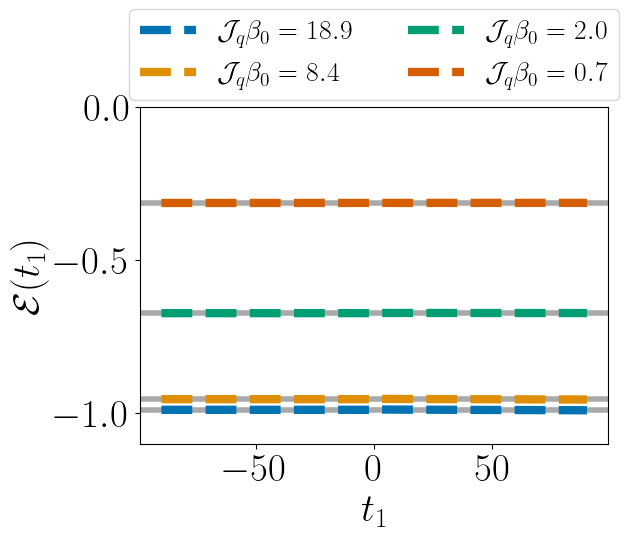

In [96]:
#  plot the energies
fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight+1))
#plt.suptitle('$\mathcal{{J}}_q=$ {}, $\mathcal{{J}}_2$ = {}, $\sigma$  ={}'.format(Jq[-1], J2[-1],sig))

print('')
for i in range(0,len(tot_E_list)):
    # ploting the energy ------------------------------------------------------
    # the true value of the energy is saved in the first value of the array
    current_E = tot_E_list[i]
    E_true = current_E[0]
    ax.axhline(E_true, c='darkgrey', linewidth=4)
    ax.plot(time_range, current_E.real,linewidth=6, 
            label=r'$\mathcal{{J}}_q\beta_{{0}}={:.1f}$'.format(beta0_list[i]),linestyle='dashed',zorder=4)
    # calculate predicted energy
    pred_E = current_E[origin_i+2:].mean()
    # calculate the change in the energy
    DE = np.diff(Et1.real, n=1)
    DE_rel = np.abs(np.divide(DE, Et1[1:].real)) # percent change
    meanDE = DE[-100:].mean()
    maxDE = DE[origin_i:].max()
    print('Energy and percentage Error for beta0 = {:.1f} ----------'.format(beta0_list[i]))
    perc_error = np.abs(pred_E-E_true)/E_true
    print('mean change in E = ', meanDE, "max change in E=",maxDE)
    print(pred_E, perc_error)
    print('')
    
    Eperc_error_list.append(perc_error)
    max_DE_list.append(maxDE)
    
ax.set_ylabel(r'$\mathcal{E}(t_1)$')
ax.set_xlabel(r'$t_1$')

ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.98),
          fancybox=True, shadow=False, fontsize=20,ncol=2,)


ax.set_ylim(-1.1,0)
plt.tight_layout()

plt.savefig(fig_route+'energy_noquench.pdf',bbox_inches='tight')

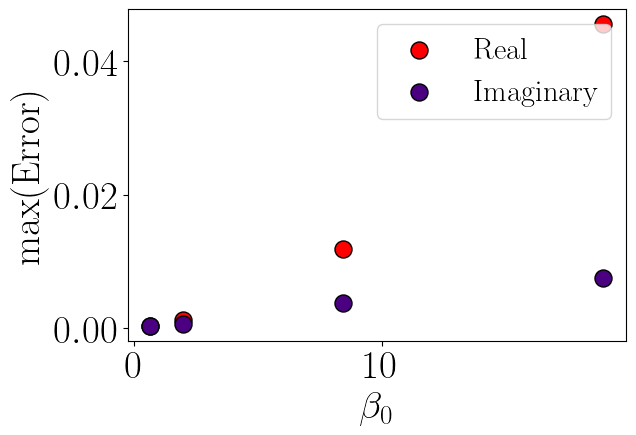

In [97]:
fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight))

plt.scatter(beta0_list,Re_serror_list, s=150, c='red', label='Real',edgecolors="black") 
plt.scatter(beta0_list,Im_serror_list, s=150, c='indigo', label='Imaginary', edgecolors="black") 

ax.set_ylabel(r'$\rm{max}(\rm{Error})$')
ax.set_xlabel(r'$\beta_0$')
ax.legend(fontsize=base_font-6)
plt.tight_layout()

plt.savefig(fig_route+'errors_noquench.pdf',bbox_inches='tight')


### Data Frame

we need the $\beta_0$, $\Delta t$, $t_{min}$, $t_{max}$, $\mathcal{E}_0$, $\mathcal{E}_f$,
$\rm{max}(\rm{Re}[\rm{Error}])$, $\rm{max}(\rm{Im}[\rm{Error}])$, $\mathcal{J}_q$

In [98]:

data_dict = {
        r"$\beta_0$":beta0_list,r"$\mathcal{J}_q$":Jq_list,r"$\Delta t$":dt_list, r"$t_{min}$":mint_list, 
        r"$t_{max}$":maxt_list, r"$\mathcal{E}_0$":trueE_list , r"$\mathcal{E}_f$":predE_list,
        r"$\rm{max}(\rm{Re}[\rm{Error}])$":Re_serror_list, r"$\rm{max}(\rm{Im}[\rm{Error}])$":Im_serror_list,
    }

data_df = pd.DataFrame.from_dict(data_dict)
data_df.to_csv("data_analysis/predictor_corrector/no_quench.csv")
data_df

,$\beta_0$,$\mathcal{J}_q$,$\Delta t$,$t_{min}$,$t_{max}$,$\mathcal{E}_0$,$\mathcal{E}_f$,$\rm{max}(\rm{Re}[\rm{Error}])$,$\rm{max}(\rm{Im}[\rm{Error}])$
0,18.936374,1.0,0.06,-90.0,90.0,-0.988686,-0.990225,0.045546,0.007458
1,8.440691,1.0,0.06,-90.0,90.0,-0.953939,-0.955106,0.011924,0.003839
2,1.993854,1.0,0.06,-90.0,90.0,-0.672607,-0.672336,0.001152,0.000643
3,0.668548,1.0,0.06,-90.0,90.0,-0.312250,-0.311966,0.000360,0.000384


## Kinetic Quench

In [99]:
# j2 = 0.003, 0.07

data_route = 'datasets/kinetic_quench/'


names_list = [
    "pred_sigma0.150000_Jtwo0.070000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    "pred_sigma0.300000_Jtwo0.070000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5", 
    "pred_sigma0.740000_Jtwo0.070000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    "pred_sigma0.950000_Jtwo0.070000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    'pred_sigma0.150000_Jtwo0.001000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5',
    'pred_sigma0.300000_Jtwo0.001000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5',
    "pred_sigma0.740000_Jtwo0.001000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5",
    'pred_sigma0.950000_Jtwo0.001000_J0.000000_dt0.060000_origin1500_mint-90.000000_maxt90.000000.h5',
            ]

beta0_list = []
sigma_list = []
tot_E_list = [] # for the energy as a fucntion of time
gn_list = []
j2_list = []
Jq_list = []
Re_serror_list = [] # for the mean squared error in the post-quench quadrants A and B
Im_serror_list = []
dt_list = []
mint_list = []
maxt_list = []
predE_list = [] # for the predicted and true energy
trueE_list = []
Eperc_error_list = [] # for the percentage error in the energy
max_DE_list = [] # maximum change in energy

for name in names_list:
    # load and prepare the data for the energy caluclation
    gn , sig, J2, Jq, dt, origin_i, mint, maxt =  kb.initialize_data(data_route,name,use_h5=True)
    theta = np.arccos(sig/Jq[0])
    print("final J2=", J2[-1]," final Jq=", Jq[-1], " dt=",dt, " min time=",mint, " max time=",maxt)
    beta0 = 2*theta*Jq[0]/sig
    print("initial beta =", beta0)
    Et1, Ekin, Eq = kb.calculate_energy(origin_i, gn, Jq, J2,dt,sig)
    # now calculate the squared errors w.r.t the exact solution
    
    # Plot an example of the absolute squared errors with med temperature 
    time_range = np.linspace(mint,maxt,len(gn))
    t1,t2 = np.meshgrid(time_range,time_range)
    # plot the MSE between the true and calculated functions for the sigma=0.74 case
    g_true = kinetic_g(t1,t2, sig,Jq[-1],J2[-1])
    # Rerr = np.max((g_true[origin_i:,origin_i:].real-gn[origin_i:,origin_i:].real))**2
    # Imerr = np.max((g_true[origin_i:,origin_i:].imag-gn[origin_i:,origin_i:].imag))**2
    arr = abs((g_true[:,origin_i:].real-gn[:,origin_i:].real)/g_true[:,origin_i:].real)
    # replace nan with zero
    arr = np.nan_to_num(arr)
    Rerr = np.max(arr)
    
    # imaginary error
    arr = abs((g_true[:,origin_i:].imag-gn[:,origin_i:].imag)/g_true[:,origin_i:].imag)
    # replace nan with zero
    arr = np.nan_to_num(arr)
    Imerr = np.max(arr)

    beta0_list.append(beta0)
    tot_E_list.append(Et1)
    gn_list.append(gn)
    sigma_list.append(sig)
    Re_serror_list.append(Rerr)
    Im_serror_list.append(Imerr)
    j2_list.append(J2[-1])
    Jq_list.append(Jq[0])
    dt_list.append(dt)
    mint_list.append(mint)
    maxt_list.append(maxt)
    predE_list.append(Et1[-1]) # for the predicted and true energy
    trueE_list.append(Et1[0])


final J2= 0.07  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 18.93637405357614


/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3123542937.py:45: RuntimeWarning: divide by zero encountered in scalar divide
  theta = np.arccos(Sigma/J)
/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3123542937.py:45: RuntimeWarning: invalid value encountered in arccos
  theta = np.arccos(Sigma/J)
/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3123542937.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  Theta = np.arccos(Sigma/J)
/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3123542937.py:34: RuntimeWarning: invalid value encountered in arccos
  Theta = np.arccos(Sigma/J)
/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3123542937.py:35: RuntimeWarning: invalid value encountered in divide
  arr = 2*np.log(Sigma/(J*np.cosh(Theta*1j + Sigma*(time1-time2))))
/var/folders/0k/k5cgw5hd6js31gjfdv_v8h7m0000gr/T/ipykernel_24508/3123542937.py:52: RuntimeWarning: invalid value encountered 

final J2= 0.07  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 8.440691151863327
final J2= 0.07  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 1.9938539687925643
final J2= 0.07  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 0.6685482721926769
final J2= 0.001  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 18.93637405357614
final J2= 0.001  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 8.440691151863327
final J2= 0.001  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 1.9938539687925643
final J2= 0.001  final Jq= 0.0  dt= 0.06  min time= -90.0  max time= 90.0
initial beta = 0.6685482721926769



J2= 0.07
Energy and percentage Error for beta0 = 18.9 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
0.0 -0.000921475798368779

J2= 0.07
Energy and percentage Error for beta0 = 8.4 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
0.0 -0.000921475798368779

J2= 0.07
Energy and percentage Error for beta0 = 2.0 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
0.0 -0.000921475798368779

J2= 0.07
Energy and percentage Error for beta0 = 0.7 ----------
mean change in E =  -5.136183829357321e-09 max change in E= 0.0002915799972530997
0.0 -0.000921475798368779



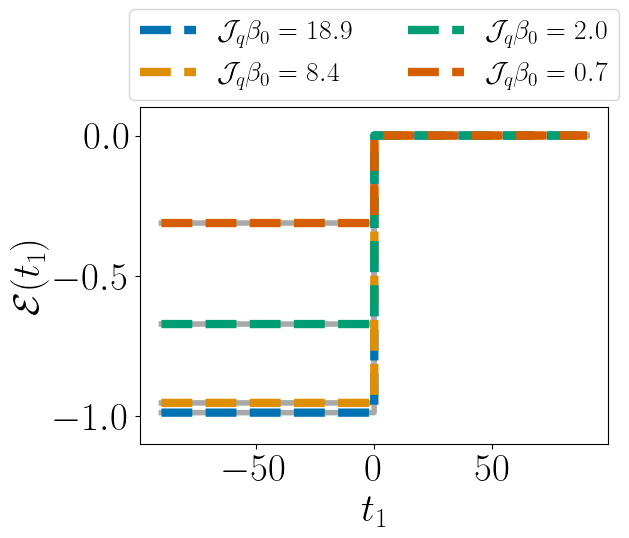

In [100]:
fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight+1))

# plot the first half
print('')
for i in range(0,int(len(tot_E_list)/2)):
    # ploting the energy ------------------------------------------------------
    # the true value of the energy is saved in the first value of the array
    print("J2=",j2_list[i])
    current_E = tot_E_list[i]
    E_true = np.zeros(len(current_E))
    E_true[:origin_i] = current_E[0]
    
        # plot the true energy
    ax.plot(time_range,E_true, linewidth=4, c="darkgrey")
    
    # Plot numerical energy
    ax.plot(time_range, current_E.real,linewidth=6, 
            label=r'$\mathcal{{J}}_q\beta_{{0}}={:.1f}$'.format(beta0_list[i]),
            linestyle='dashed',zorder=4)
    
    # calculate predicted energy
    pred_E = current_E[origin_i+2:].mean()
    # calculate the change in the energy
    """DE = np.diff(Et1.real, n=1)
    DE_rel = np.abs(np.divide(DE, Et1[1:].real)) # percent change
    meanDE = DE[-100:].mean()
    maxDE = DE[origin_i:].max()"""
    print('Energy and percentage Error for beta0 = {:.1f} ----------'.format(beta0_list[i]))
    # perc_error = np.abs(pred_E-E_true)/E_true
    print('mean change in E = ', meanDE, "max change in E=",maxDE)
    print(pred_E, perc_error)
    print('')
    
    Eperc_error_list.append(perc_error)
    max_DE_list.append(maxDE)
    
ax.set_ylabel(r'$\mathcal{E}(t_1)$')
ax.set_xlabel(r'$t_1$')

ax.legend(loc='lower center', bbox_to_anchor=(0.5, 0.98),
          fancybox=True, shadow=False, fontsize=20,ncol=2,)
ax.set_ylim(-1.1,0.1)
plt.tight_layout()

plt.savefig(fig_route+'energy_kineticquench.pdf',bbox_inches='tight')


[np.float64(0.07), np.float64(0.07), np.float64(0.07), np.float64(0.07)]


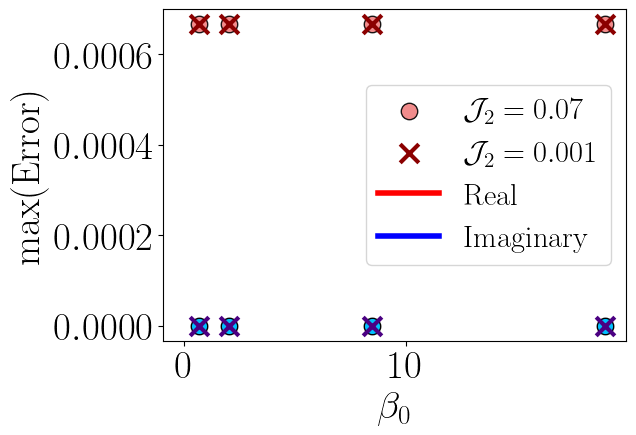

In [11]:
# define the "cutoff" indices where each of the J2 changes
cut_1 = 4
cut_2 = 8

fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight))

print(j2_list[:cut_1])

plt.scatter(beta0_list[:cut_1],Re_serror_list[:cut_1], s=140, c='lightcoral',
            edgecolors="black", label=r"$\mathcal{{J}}_2= 0.07$", alpha=0.9) 
plt.scatter(beta0_list[:cut_1],Im_serror_list[:cut_1], s=140, c='deepskyblue',edgecolors="black")  

# for the next J2
plt.scatter(beta0_list[cut_1:cut_2],Re_serror_list[cut_1:cut_2], s=180, c='darkred', label=r"$\mathcal{{J}}_2= 0.001$",
            marker="x", linewidth=3) 
plt.scatter(beta0_list[cut_1:cut_2],Im_serror_list[cut_1:cut_2], s=180, c='indigo', 
            marker="x",linewidth=3) 

plt.plot(0,0, linewidth= 4,color='red', label="Real")
plt.plot(0,0, linewidth= 4,color='blue', label="Imaginary")

ax.set_ylabel(r'$\rm{max}(\rm{Error})$')
ax.set_xlabel(r'$\beta_0$')
ax.legend(fontsize=base_font-6, loc="center right")
plt.tight_layout()

plt.savefig(fig_route+'errors_kineticquench.pdf',bbox_inches='tight')


### Data Frame

In [12]:

data_dict = {
        r"$\beta_0$":beta0_list,r"$\mathcal{J}_q$":Jq_list,r"$\Delta t$":dt_list, r"$t_{min}$":mint_list, 
        r"$t_{max}$":maxt_list, r"$\mathcal{E}_0$":trueE_list , r"$\mathcal{E}_f$":predE_list,
        r"$\rm{max}(\rm{Re}[\rm{Error}])$":Re_serror_list, r"$\rm{max}(\rm{Im}[\rm{Error}])$":Im_serror_list,
    }

data_df = pd.DataFrame.from_dict(data_dict)
data_df.to_csv("data_analysis/predictor_corrector/kinetic_quench.csv")

data_df

,$\beta_0$,$\mathcal{J}_q$,$\Delta t$,$t_{min}$,$t_{max}$,$\mathcal{E}_0$,$\mathcal{E}_f$,$\rm{max}(\rm{Re}[\rm{Error}])$,$\rm{max}(\rm{Im}[\rm{Error}])$
0,18.936374,1.0,0.06,-90.0,90.0,-0.988686,0.0,0.000667,0.0
1,8.440691,1.0,0.06,-90.0,90.0,-0.953939,0.0,0.000667,0.0
2,1.993854,1.0,0.06,-90.0,90.0,-0.672607,0.0,0.000667,0.0
3,0.668548,1.0,0.06,-90.0,90.0,-0.312250,0.0,0.000667,0.0
4,18.936374,1.0,0.06,-90.0,90.0,-0.988686,0.0,0.000667,0.0
5,8.440691,1.0,0.06,-90.0,90.0,-0.953939,0.0,0.000667,0.0
6,1.993854,1.0,0.06,-90.0,90.0,-0.672607,0.0,0.000667,0.0
7,0.668548,1.0,0.06,-90.0,90.0,-0.312250,0.0,0.000667,0.0


# Figure for Beta and gamma

This one is presented as all of the data

First load all the temperature dataframes and merge them into one for easier analysis

In [13]:
data_route = "data_analysis/predictor_corrector/"
im15 = pd.read_csv(data_route+"sigma0.15/data_sig0.15_2p.csv").drop('Unnamed: 0',axis=1)
im15 = im15.drop_duplicates()

data_route = "data_analysis/predictor_corrector/"
im3 = pd.read_csv(data_route+"sigma0.3/data_sig0.3_2p.csv").drop('Unnamed: 0',axis=1)
im3 = im3.drop_duplicates()

data_route = "data_analysis/predictor_corrector/"
im74 = pd.read_csv(data_route+"sigma0.74/data_sig0.74_2p.csv").drop('Unnamed: 0',axis=1)
im74 = im74.drop_duplicates()

data_route = "data_analysis/predictor_corrector/"
im95 = pd.read_csv(data_route+"sigma0.95/data_sig0.95_2p.csv").drop('Unnamed: 0',axis=1)
im95 = im95.drop_duplicates()

data_df = pd.concat([im15,im3,im74,im95], axis=0)
data_df = data_df.dropna()
data_df['Tf'] = 1/data_df['betaf']

# drop non relevant values
data_df = data_df[(data_df['beta0']>1.0) & (data_df['J2']>0.002) & (data_df['J2']<=0.07)]

data_df["E_Rel_error"] = np.abs((data_df["E0"] - data_df["Ef"] )/data_df["E0"])
data_df["Int_Rel_error"] = np.abs((data_df["Neq_Int"] - data_df["thermal_int"] )/data_df["Neq_Int"])


### Dataframe

In [14]:
cols_ = ["dt","maxt", "Jq","J2","beta0","E0", "betaf", "Ef","max_dE", "E_Rel_error",
        'EGamma', 'Econst', 'Eampli', "EMSE","Neq_Int","thermal_int","Int_Rel_error"]
save_df = data_df[cols_].copy()
save_df.rename(columns={'dt':'$\Delta t$', "maxt":"$t_{\text{max}}$","Jq":"$\mathcal{J}_q$", "J2":"$\mathcal{J}_2$",
                "beta0":r"$\beta_0$", "E0":"$\mathcal{E}_0$","betaf":r"$\beta_f$", "Ef":"$\mathcal{E}_f$",
                "max_dE":"$\Delta \mathcal{E}(t)_{\text{max}}$","E_Rel_error":r"$\text{Rel,Err}(\mathcal{E}_f)$",
                "EGamma":"$\gamma$","Econst":"$B_{\mathcal{K}}$", "Eampli":"$C_{\mathcal{K}}$",
                "EMSE": "$\text{MSE}_{\mathcal{K}}$", "Neq_Int":"$\mathcal{V}(t_f)$",
                "thermal_int":r"$\mathcal{V}_{\text{EQ}}(\beta)$", 
                "Int_Rel_error":r"$\text{Rel,Err}(\mathcal{V}(t_f))$"
                       }, inplace=True)

save_df.to_csv("data_analysis/predictor_corrector/mixed_quench.csv")

save_df.head()


,$\Delta t$,$t_{\text{max}}$,$\mathcal{J}_q$,$\mathcal{J}_2$,$\beta_0$,$\mathcal{E}_0$,$\beta_f$,$\mathcal{E}_f$,$\Delta \mathcal{E}(t)_{\text{max}}$,"$\text{Rel,Err}(\mathcal{E}_f)$",$\gamma$,$B_{\mathcal{K}}$,$C_{\mathcal{K}}$,$\text{MSE}_{\mathcal{K}}$,$\mathcal{V}(t_f)$,$\mathcal{V}_{\text{EQ}}(\beta)$,"$\text{Rel,Err}(\mathcal{V}(t_f))$"
0,0.05,1700.0,1.0,0.003,18.936374,-0.988686,10.000000,-1.013824,0.000443,0.025425,0.000036,-0.713717,0.713745,9.817652e-12,-0.971995,-0.965234,0.006956
1,0.05,1700.0,1.0,0.004,18.936374,-0.988686,7.236948,-1.011919,0.000443,0.023499,0.000083,-0.540548,0.540545,4.454848e-10,-0.940909,-0.940885,0.000026
2,0.05,1700.0,1.0,0.005,18.936374,-0.988686,5.277108,-1.009818,0.000443,0.021374,0.000127,-0.544914,0.544816,3.358951e-09,-0.903951,-0.903843,0.000119
3,0.05,1700.0,1.0,0.006,18.936374,-0.988686,4.120482,-1.007660,0.000443,0.019191,0.000170,-0.576962,0.576690,1.351685e-08,-0.862315,-0.862904,0.000683
4,0.05,1700.0,1.0,0.007,18.936374,-0.988686,3.317269,-1.005551,0.000443,0.017058,0.000214,-0.615768,0.615230,3.907541e-08,-0.817093,-0.817026,0.000082


In [15]:
sigma_list = [0.15,0.3, 0.74]
marker_list = ['s','^','o','D']
color_list = ["green", "royalblue","orange","pink"]


## $\beta_f$ vs $J_2$

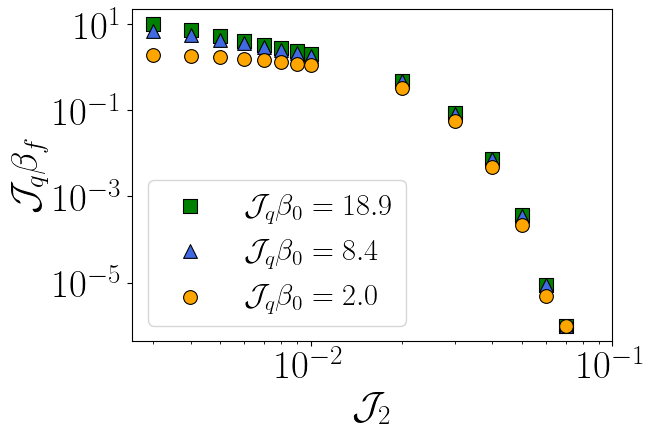

In [16]:
fig, ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

# plot temperature as a function of kinetic coupling
for i in range(0,len(sigma_list)):
    curr_df = data_df[data_df['sigma']==sigma_list[i]]
    sns.scatterplot(data=curr_df, x='J2', y='betaf', ax=ax, s=98,edgecolor='black',
                    marker=marker_list[i],label=r'$\mathcal{{J}}_q\beta_0={:.1f}$'.format(curr_df['beta0'].unique()[0]), 
                    color=color_list[i])

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel(r'$\mathcal{J}_2$')
ax.set_ylabel(r'$\mathcal{J}_q \beta_f$')

ax.set_xticks([10**(-2), 10**(-1)])
#ax.xaxis.set_major_locator(plt.MaxNLocator(10))
plt.legend(fontsize=base_font-6)
plt.tight_layout()

plt.savefig(fig_route+'final_betas_J2.pdf',bbox_inches='tight',dpi=300)


## $\gamma$ vs $\beta_f$ 

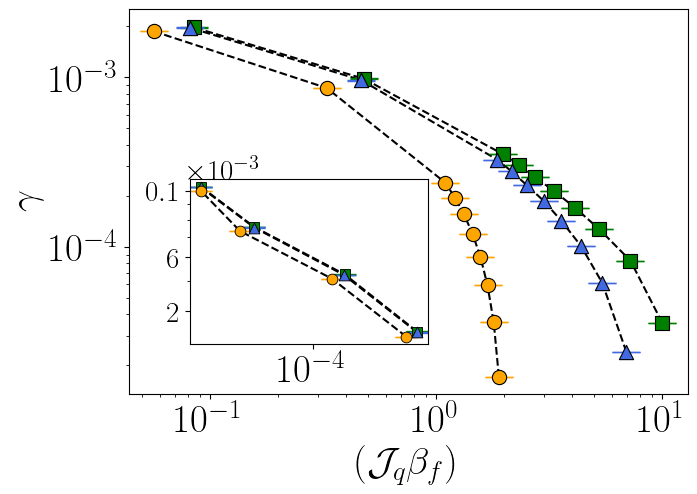

In [17]:

fig, ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))
# add inset
left, bottom, width, height = [0.21, 0.21, 0.33, 0.33]
ax2 = fig.add_axes([left, bottom, width, height])

betamin = 10**(-2)

for i in range(0,len(sigma_list)):
    curr_df = data_df[(data_df['sigma']==sigma_list[i])& (data_df['betaf']>betamin)]
    
    ax.errorbar(curr_df['betaf'], curr_df['EGamma'], yerr=curr_df['EMSE'], capsize=10, ecolor=color_list[i],
                 barsabove=True, c='black', linestyle='dashed')
    
    sns.scatterplot(data=curr_df, x='betaf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, 
                    color=color_list[i],marker = marker_list[i])
    # for the inset
    curr_df = data_df[(data_df['sigma']==sigma_list[i])& (data_df['betaf']<=betamin) ]
    ax2.errorbar(curr_df['betaf'], curr_df['EGamma'], yerr=curr_df['EMSE'], capsize=8, ecolor=color_list[i],
                 barsabove=True, c='black', linestyle='dashed')
    
    sns.scatterplot(data=curr_df, x='betaf', y='EGamma', ax=ax2, s=60,edgecolor='black',zorder=5, 
                    color=color_list[i],marker = marker_list[i])


    
# aesthetics -------------------------------------------------------------------------------- 
# set inset tickes
ax2.set_ylabel("")
ax2.set_xlabel("")
ax2.set_xscale('log')
ax2.set_yscale('log')
#ax2.ticklabel_format(axis='both', style='sci', scilimits=(0,0))

ax2.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax2.set_yticks([0.01,0.006,0.004],[r"$0.1$",r"$6$",r"$2$"] , fontsize=base_font-7)
#ax2.tick_params(axis='both', which='both', labelsize=base_font-7)
ax.annotate(r"$\times 10^{-3}$", xy=(0.08,0.00026), fontsize=base_font-7)


#ax.set_ylim(0.00001,0.1)
ax.set_ylabel(r'$\gamma$')
#ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_xlabel(r'$(\mathcal{J}_q\beta_f)$')

ax.set_xscale('log')
ax.set_yscale('log')
#ax.legend(fontsize=base_font-7)
#plt.tight_layout()
plt.savefig(fig_route+'final_betas_gamma.pdf',bbox_inches='tight',dpi=300)



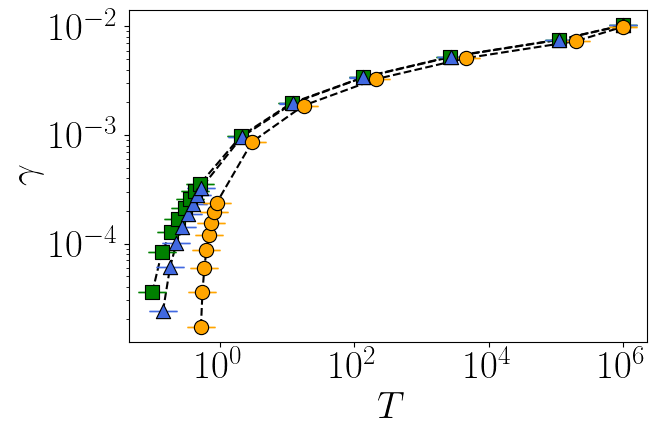

In [18]:

fig, ax = plt.subplots(1,1,figsize=(1.03*bwidth,bheight))

for i in range(0,len(sigma_list)):
    curr_df = data_df[data_df['sigma']==sigma_list[i]]
    
    ax.errorbar(curr_df['Tf'], curr_df['EGamma'], yerr=curr_df['EMSE'], capsize=10, ecolor=color_list[i],
                 barsabove=True, c='black', linestyle='dashed')
    
    sns.scatterplot(data=curr_df, x='Tf', y='EGamma', ax=ax, s=105,edgecolor='black',zorder=5, 
                    color=color_list[i],marker = marker_list[i])
    
# aesthetics -------------------------------------------------------------------------------- 
#ax.set_ylim(0.00001,0.1)
#ax.set_xlim(0.000002,15)
ax.set_ylabel(r'$\gamma$')
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.set_xlabel(r'$T$')

ax.set_xscale('log')
ax.set_yscale('log')
#ax.legend(fontsize=base_font-7)
plt.tight_layout()

plt.savefig(fig_route+'final_T_gamma.pdf',bbox_inches='tight',dpi=300)


# Examples for figures

These are three examples of thermalization and stationarity. Consisting of the two-time plots and the energy

## Load data

use j2 = 0.03 and 0.005 as examples

In [116]:
data_route = "data_analysis/predictor_corrector/sigma0.15/"
# Tdat_sig0.150_Jtwo0.003_dt0.050_jq1.000_tmax1700.0.h5
# Tdat_sig0.150_Jtwo0.020_dt0.050_jq1.000_tmax1700.0.h5
# Tdat_sig0.150_Jtwo0.070_dt0.050_jq1.000_tmax1700.0.h5

str_name = "Tdat_sig0.150_Jtwo0.070_dt0.050_jq1.000_tmax1700.0.h5"

J2_mag, Jq_mag, dt, maxt, sig = read_parameters(str_name)

print(J2_mag, Jq_mag, dt, maxt, sig)

0.07 1.0 0.05 1700.0 0.15


In [117]:
# only if we want to try plotting the two time plane here but I have a script for that
"""# load the raw data
raw_route = "datasets/mixed_quench/"
raw_name = "pred_sigma0.150000_Jtwo0.010000_J1.000000_dt0.050000_origin3000_mint-150.000000_maxt1700.000000.h5"

gn , sig, _, _, _, origin_i, mint, maxt =  kb.initialize_data(raw_route,raw_name,use_h5=True)
"""

'# load the raw data\nraw_route = "datasets/mixed_quench/"\nraw_name = "pred_sigma0.150000_Jtwo0.010000_J1.000000_dt0.050000_origin3000_mint-150.000000_maxt1700.000000.h5"\n\ngn , sig, _, _, _, origin_i, mint, maxt =  kb.initialize_data(raw_route,raw_name,use_h5=True)\n'

In [118]:
# Dictionary for the wigner coord slices
Tau_dict = {}

# read off the data
f = h5py.File(data_route+str_name, 'r')

print(f.keys())
print(f["G_tau"].keys())
Tau_times = list(f["G_tau"].keys())
# save the Gtau
for key in Tau_times:
    Tau_dict[key] = f["G_tau"][key][:]
    
# load derivatives along diaongals
D_time = {}
D_real = {}
D_imag = {}

print(list(f["Diagonal_deriv"].keys()))
time_keys = list(f["Diagonal_deriv"]["Times_Deriv"].keys())
re_keys = list(f["Diagonal_deriv"]["Re_Deriv"].keys())
im_keys = list(f["Diagonal_deriv"]["Im_Deriv"].keys())

for i in range(0,len(time_keys)):
    tkey = time_keys[i]
    rkey = re_keys[i]
    ikey = re_keys[i]
    
    D_time[tkey]= f["Diagonal_deriv"]["Times_Deriv"][tkey][:]
    D_real[rkey]= f["Diagonal_deriv"]["Re_Deriv"][rkey][:]
    D_imag[ikey]= f["Diagonal_deriv"]["Im_Deriv"][ikey][:]
    
# save the energy
Ekin = f["Energy"]["kinetic"][:]
Eq = f["Energy"]["interaction"][:]
Et1 = Ekin + Eq
time_range = f["Energy"]["timerange"][:]

f.close()

<KeysViewHDF5 ['Diagonal_deriv', 'Energy', 'G_tau']>
<KeysViewHDF5 ['G225', 'G250', 'G275', 'G300', 'G325', 'G350', 'G400', 'G450', 'G500', 'G550', 'G600', 'G650', 'G700', 'G750', 'G800', 'G850']>
['Im_Deriv', 'Re_Deriv', 'Times_Deriv']


## Figures for two time plot Generate the Two time plot latex labels and ticks

since rocks does not want to cooperate with latex I have to do this by hand


In [119]:
def component_contour(g_matrix, Tmin, Tmax,cbar_loc, cbar_lab ,bwidth=7, axis_font=20):    
    # makes a contour plot
    valnorm = abs(g_matrix.min())
    fig, ax = plt.subplots(1,1,figsize=(bwidth,bwidth))

    im = ax.contourf(g_matrix.real, extent=[Tmin, Tmax,Tmin,Tmax],
                      cmap='seismic', vmin=-valnorm,vmax=valnorm)
    
    # plot guiding lines for the quadrants
    ax.scatter(0,0, c='grey',s=50)
    ax.axvline(0, c='grey',linewidth=2, linestyle='dashed')
    ax.axhline(0, c='grey',linewidth=2, linestyle='dashed')
    ax.set_ylabel(r'$t_2$', fontsize=axis_font)
    ax.set_xlabel(r'$t_1$',fontsize=axis_font)
    ax.tick_params(axis='both', which='major', labelsize=axis_font)
    ax.tick_params(axis='both', which='minor', labelsize=axis_font)
    
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    cbar = fig.colorbar(im, cax, shrink=0.9)    
    cbar.ax.tick_params(labelsize=axis_font-3)
    cbar.set_ticks(cbar_loc)
    cbar.set_ticklabels(cbar_lab)
    cbar.formatter.set_powerlimits((0, 0))
    return fig, ax

## Energy 

0.0016449837
0.0016449837


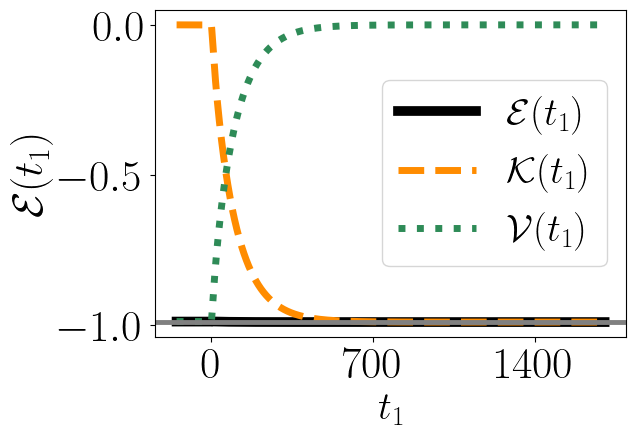

In [133]:
# the estimated part of interest is the one after the quench 
estimated_E = np.mean(Et1[-500:-1])
perc_change = abs((Et1[0] - Et1[-1])/Et1[0])
print(perc_change)

fig, ax = plt.subplots(1,1,figsize=(bwidth,bheight))

# ploting the energy ------------------------------------------------------
plot_from = 1 # index indicating first time step for the enrgy plot
ax.plot(time_range, Et1.real,linewidth=7, 
        c='black', label=r'$\mathcal{E}(t_1)$')
ax.plot(time_range, Ekin.real,linewidth=5, c='darkorange', 
        linestyle='dashed',label=r'$\mathcal{K}(t_1)$')
ax.plot(time_range, Eq.real,linewidth=5, c='seagreen',
        linestyle ='dotted', label=r'$\mathcal{V}(t_1)$')

# plt.title(r"$|E_f - E_0 / E_0|={:.3f}$".format(perc_change))
print(perc_change)
plt.axhline(Et1[0], c='grey',linewidth=3.5)

# aesthetics ------------------------
ax.set_ylabel(r'$\mathcal{E}(t_1)$', fontsize = base_font+3)
ax.set_xlabel(r'$t_1$')
ax.legend(fontsize=base_font-3)
"""axchange.set_ylabel(r'$\Delta \mathcal{E}(t_1)/\mathcal{E}(t_1)$')
axchange.set_ylim(-0.0007,0.01)"""

ax.set_xticks([0, 700, 1400])

plt.xticks(fontsize=base_font+4)
plt.yticks(fontsize=base_font+4)


ax.legend(loc='center right')

"""ax.legend(loc='upper center', bbox_to_anchor=(0.45, 1.2),
          fancybox=True, shadow=False, ncol=5,fontsize=20)
"""
plt.tight_layout()

plt.savefig(fig_route+'E_mixed_Jtwo{}_sig{}.pdf'.format(J2_mag,sig))

## Diagonals

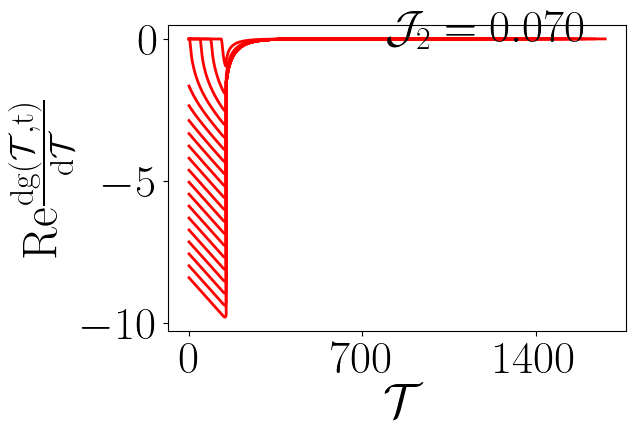

In [121]:
fig, ax = plt.subplots(1,1, figsize=(bwidth, bheight))

for i in range(0,len(time_keys)):
    # calculate the time range
    ax.plot(D_time[time_keys[i]],D_real[re_keys[i]], c = 'red',linewidth = 2 ) 
    
ax.set_xlabel(r"$\mathcal{T}$", fontsize=base_font+7)
ax.set_ylabel(r"$\rm{Re}\frac{d g(\mathcal{T},t)}{d\mathcal{T}}$",fontsize=base_font+7)
# for 0.003
ax.annotate(r'$\mathcal{{J}}_2={:.3f}$'.format(J2_mag), xy=(800,-0.09),fontsize=base_font+5)
# for 0.02
#ax.annotate(r'$\mathcal{{J}}_2={:.2f}$'.format(J2_mag), xy=(900,-1.3),fontsize=base_font+5)
# for 0.07
#ax.annotate(r'$\mathcal{{J}}_2={:.2f}$'.format(J2_mag), xy=(900,-5),fontsize=base_font+5)

plt.xticks(fontsize=base_font+5)
ax.set_xticks([0, 700, 1400])
plt.yticks(fontsize=base_font+5)

plt.tight_layout()

plt.savefig(fig_route+'Re_diagonals_Jtwo{:.3f}_sig{:.3f}.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)


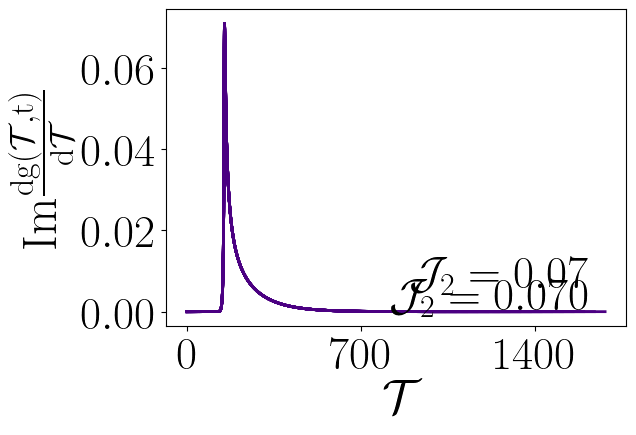

In [122]:
fig, ax = plt.subplots(1,1, figsize=(bwidth, bheight))

for i in range(0,len(time_keys)):
    # calculate the time range
    ax.plot(D_time[time_keys[i]],D_imag[re_keys[i]], c = 'indigo',linewidth = 2 ) 
    
# For J2 = 0.07
#ax.annotate(r'$\mathcal{{J}}_2={:.2f}$'.format(J2_mag), xy=(900,0.04),fontsize=base_font+5)
# For J2 = 0.02
ax.annotate(r'$\mathcal{{J}}_2={:.2f}$'.format(J2_mag), xy=(900,0.006),fontsize=base_font+5)
# For J2 = 0.092
ax.annotate(r'$\mathcal{{J}}_2={:.3f}$'.format(J2_mag), xy=(820,0.0006),fontsize=base_font+5)


ax.set_xlabel(r"$\mathcal{T}$", fontsize=base_font+7)
ax.set_ylabel(r"$\rm{Im}\frac{d g(\mathcal{T},t)}{d\mathcal{T}}$",fontsize=base_font+7)
plt.xticks(fontsize=base_font+5)
ax.set_xticks([0, 700, 1400])
plt.yticks(fontsize=base_font+5)

plt.tight_layout()

plt.savefig(fig_route+'Im_diagonals_Jtwo{:.3f}_sig{:.3f}.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)


## Gtau double plot real and imaginary

['G225', 'G300', 'G400', 'G550', 'G700', 'G850']


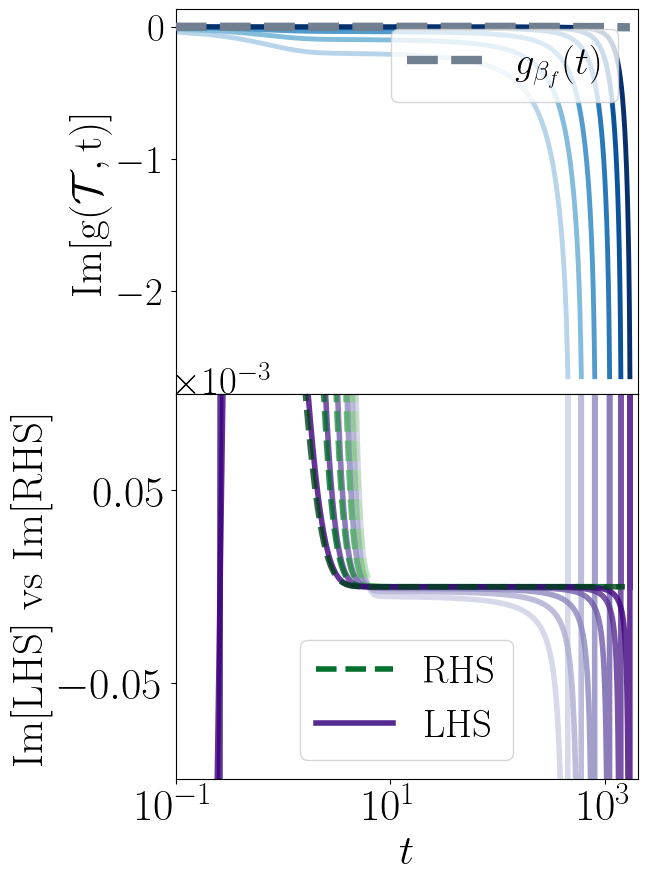

In [123]:
# CHoose less Tau for better view
Tau_choose = Tau_times[::3]

print(Tau_choose)

colors = plt.cm.Blues(np.linspace(0.3,1,len(Tau_choose)))
colors_LHS = plt.cm.Purples(np.linspace(0.3,1,len(Tau_choose)))
colors_RHS = plt.cm.Greens(np.linspace(0.3,1,len(Tau_choose)))

# Now estimate the derivative from the maximum gtau to avoid guesswork in the temperature
# get the g(T,t) at the maximum T and calculate thermal from this
g_tau = Tau_dict[Tau_times[-1]]
tzero = int(len(g_tau)/2)
# initial condition of derivative
gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
g_tau = np.flip(g_tau[:tzero])
t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

# for the thermal solution use the derivative from NEQ as initial condition to avoid guesswork
Dt = 2*dt
tsteps = len(g_tau)
ialpha = gprime 
g_thermal, _,eq_time = kb.solution_to_thermal(tsteps, 0, ialpha, Dt, Jq_mag,J2_mag)

fig, ax = plt.subplots(nrows=2, sharex=True, figsize= (bwidth,2*bheight)) 
plt.subplots_adjust(hspace=.0)

# place holder for rhs lhs labels
ax[1].plot(0,0,linewidth=4,linestyle='dashed',c=colors_RHS[-2], label=r'RHS')
ax[1].plot(0,0,linewidth=4,linestyle='solid',c=colors_LHS[-2], label=r'LHS')


# plot equilibrium solution
ax[0].plot(t_, g_thermal.imag,linewidth=6,  c='slategrey',zorder=5, linestyle='dashed', 
           label=r'$g_{\beta_{f}}(t)$')
i = 0
for tau in Tau_choose:
    g_tau = Tau_dict[tau]
    tzero = int(len(g_tau)/2)
    # initial condition of derivative
    gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
    g_tau = np.flip(g_tau[:tzero])
    t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))
    # comparing the RHS and LHS of the thermal equation using the KB solution
    dg_lhs =  LHS(g_tau, gprime, Dt)
    g_RHS = RHS(g_tau,Jq_mag, J2_mag)

    ax[0].plot(t_, g_tau.imag,linewidth=3.5,linestyle='solid', c=colors[i])
    
    ax[1].plot(t_[1:],dg_lhs.imag,linewidth=4,c=colors_LHS[i], alpha=0.8)
    ax[1].plot(t_[1:],g_RHS.imag,linewidth=4,linestyle='dashed',c=colors_RHS[i],alpha=0.8)
    
    i = i+1

# plot the line where the solution leaves stationarity
# ax[0].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)
# ax[1].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)

# aesthetics
ax[0].set_ylabel(r"$\rm{Im}[g(\mathcal{T},t)]$",fontsize=base_font+3)
ax[0].legend(fontsize=base_font, loc="upper right")
ax[1].legend(fontsize=base_font, loc="lower center")

ax[1].set_xlabel(r"$t$", fontsize=base_font+3)
ax[1].set_ylabel(r"Im[LHS] vs Im[RHS]",fontsize=base_font+3)

plt.xticks(fontsize=base_font+4)
plt.yticks(fontsize=base_font+4)

# move scie notation
ax[1].ticklabel_format(axis='both', style='sci', scilimits=(-3,-3))

# for J2 = 0.003 and J2 = 0.02 and J2 = 0.07
ax[0].set_xlim(0.1,2000)
ax[1].set_ylim(-0.0001,0.0001)
ax[1].set_yticks([0.00005, -0.00005])


#t = ax[1].yaxis.get_offset_text()
#t.set_x(0.02)
# set number of ticks
# ax[1].xaxis.set_major_locator(ticker.MultipleLocator(400))

# use logscale 
ax[0].set_xscale('log')

plt.subplots_adjust(left=0.24)

plt.savefig(fig_route+'mixed_Imgtau_Jtwo{:.3f}_sig{:.3f}.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)


['G225', 'G300', 'G400', 'G550', 'G700', 'G850']


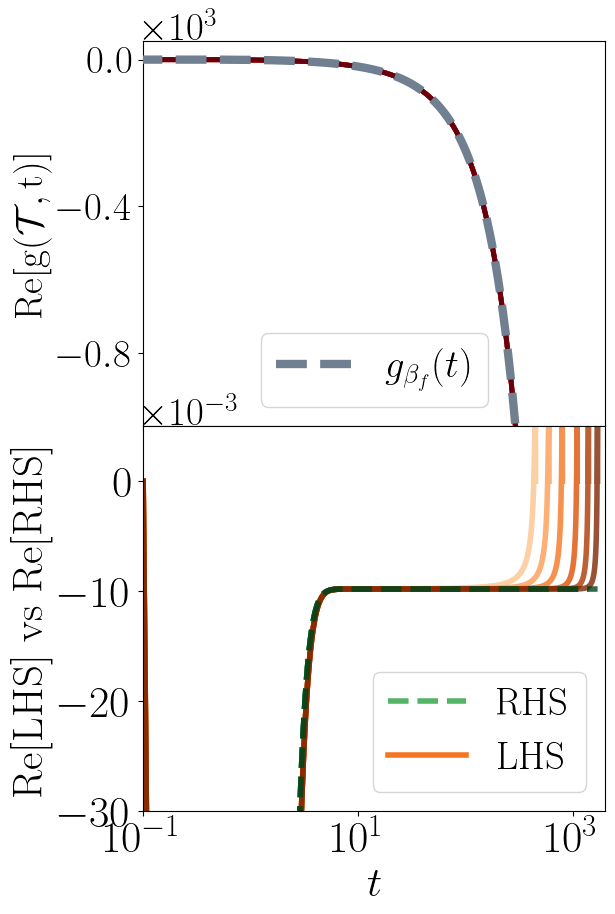

In [130]:
print(Tau_choose)

colors = plt.cm.Reds(np.linspace(0.3,1,len(Tau_choose)))
colors_LHS = plt.cm.Oranges(np.linspace(0.3,1,len(Tau_choose)))
colors_RHS = plt.cm.Greens(np.linspace(0.3,1,len(Tau_choose)))

# Now estimate the derivative from the maximum gtau to avoid guesswork in the temperature
# get the g(T,t) at the maximum T and calculate thermal from this
g_tau = Tau_dict[Tau_times[-1]]
tzero = int(len(g_tau)/2)
# initial condition of derivative
gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
g_tau = np.flip(g_tau[:tzero])
t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

# for the thermal solution use the derivative from NEQ as initial condition to avoid guesswork
Dt = 2*dt
tsteps = len(g_tau)
ialpha = gprime 
g_thermal, _,eq_time = kb.solution_to_thermal(tsteps, 0, ialpha, Dt, Jq_mag,J2_mag)


fig, ax = plt.subplots(nrows=2, sharex=True, figsize= (bwidth,2*bheight)) 
plt.subplots_adjust(hspace=.0)

# place holder for rhs lhs labels
ax[1].plot(0,0,linewidth=4,linestyle='dashed',c=colors_RHS[-4], label=r'RHS')
ax[1].plot(0,0,linewidth=4,linestyle='solid',c=colors_LHS[-4], label=r'LHS')

# plot equilibrium solution
ax[0].plot(t_, g_thermal.real,linewidth=6,  c='slategrey',zorder=5, linestyle='dashed', 
           label=r'$g_{\beta_{f}}(t)$')
i = 0
for tau in Tau_choose:
    g_tau = Tau_dict[tau]
    tzero = int(len(g_tau)/2)
    # initial condition of derivative
    gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
    g_tau = np.flip(g_tau[:tzero])
    t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))
    # comparing the RHS and LHS of the thermal equation using the KB solution
    dg_lhs =  LHS(g_tau, gprime, Dt)
    g_RHS = RHS(g_tau,Jq_mag, J2_mag) 

    ax[0].plot(t_, g_tau.real,linewidth=3.5,linestyle='solid', c=colors[i])
    
    ax[1].plot(t_[1:],dg_lhs.real,linewidth=4,c=colors_LHS[i], alpha = 0.8)
    ax[1].plot(t_[1:],g_RHS.real,linewidth=4,linestyle='dashed',c=colors_RHS[i],alpha=0.8)
    
    i = i+1

# plot the line where the solution leaves stationarity
# ax[0].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)
# ax[1].axvline(350, c='black', linestyle='dotted' ,linewidth = 3)

# aesthetics
ax[0].set_ylabel(r"$\rm{Re}[g(\mathcal{T},t)]$")
# ax[0].legend(fontsize=base_font-4.5, bbox_to_anchor=(0.98, 1.0))
ax[0].legend(fontsize=base_font, loc="lower center")
ax[1].legend(fontsize=base_font, loc="lower center")

ax[1].set_xlabel(r"$t$",fontsize=base_font+3)
ax[1].set_ylabel(r"Re[LHS] vs Re[RHS]",fontsize=base_font+3)

# for J2 = 0.02
"""ax[0].set_xlim(0.1,2000)
ax[0].set_yticks([0, -1800, -3500])
ax[1].set_ylim(-0.009,0.009)"""

# for J2 = 0.003
ax[0].set_xlim(0.1,2000)
ax[0].set_yticks([0, -400, -800])
ax[0].set_ylim(-1000,50)
ax[1].set_ylim(-0.009,0.009)


# for J2 = 0.07
ax[1].set_ylim(-0.03,0.005)

plt.xticks(fontsize=base_font+4)
plt.yticks(fontsize=base_font+4)

# move scie notation
ax[0].ticklabel_format(axis='both', style='sci', scilimits=(3,3))
ax[1].ticklabel_format(axis='both', style='sci', scilimits=(-3,-3))

#t = ax[1].yaxis.get_offset_text()
#t.set_x(0.02)
# set number of ticks
# ax[1].xaxis.set_major_locator(ticker.MultipleLocator(400))

# use logscale 
ax[0].set_xscale('log')

ax[1].legend(loc='lower right')

plt.subplots_adjust(left=0.24)

plt.savefig(fig_route+'mixed_Retau_Jtwo{:.3f}_sig{:.3f}.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)

# Gtau Imaginary Real Sepparate

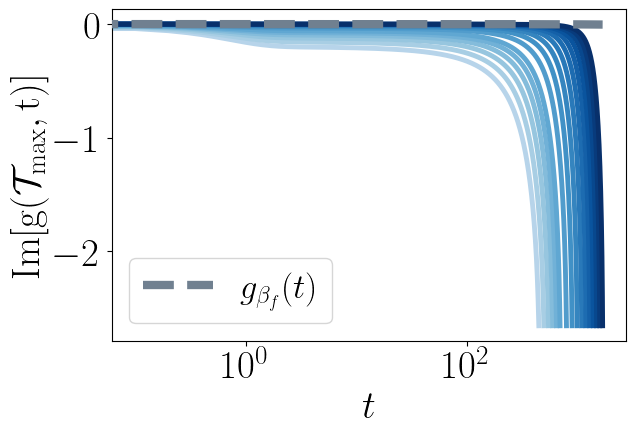

In [125]:
colors = plt.cm.Blues(np.linspace(0.3,1,len(Tau_times)))

# Now estimate the derivative from the maximum gtau to avoid guesswork in the temperature
# get the g(T,t) at the maximum T and calculate thermal from this
g_tau = Tau_dict[Tau_times[-1]]
tzero = int(len(g_tau)/2)
# initial condition of derivative
gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
g_tau = np.flip(g_tau[:tzero])
t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))

# for the thermal solution use the derivative from NEQ as initial condition to avoid guesswork
Dt = 2*dt
tsteps = len(g_tau)
ialpha = gprime 
g_thermal, _,eq_time = kb.solution_to_thermal(tsteps, 0, ialpha, Dt, Jq_mag,J2_mag)

fig, ax = plt.subplots(1, figsize= (bwidth,bheight)) 
plt.subplots_adjust(hspace=.0)

# plot equilibrium solution
ax.plot(t_, g_thermal.imag,linewidth=6,  c='slategrey',zorder=5, linestyle='dashed', 
           label=r'$g_{\beta_{f}}(t)$')
i = 0
for tau in Tau_times:
    g_tau = Tau_dict[tau]
    tzero = int(len(g_tau)/2)
    # initial condition of derivative
    gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
    g_tau = np.flip(g_tau[:tzero])
    t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))
    # comparing the RHS and LHS of the thermal equation using the KB solution
    dg_lhs =  LHS(g_tau, gprime, dt)
    g_RHS = RHS(g_tau,J2_mag, Jq_mag)

    ax.plot(t_, g_tau.imag,linewidth=3.5,linestyle='solid', c=colors[i])
    
    i = i+1
    
ax.set_xscale('log')

# aesthetics
ax.set_ylabel(r"$\rm{Im}[g(\mathcal{T}_{\rm max},t)]$")
ax.legend(fontsize=base_font-3)
ax.set_xlabel(r"$t$")

plt.tight_layout()

# plt.savefig(fig_route+'sep_Imgtau_Jtwo{:.3f}_sig{:.3f}.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)


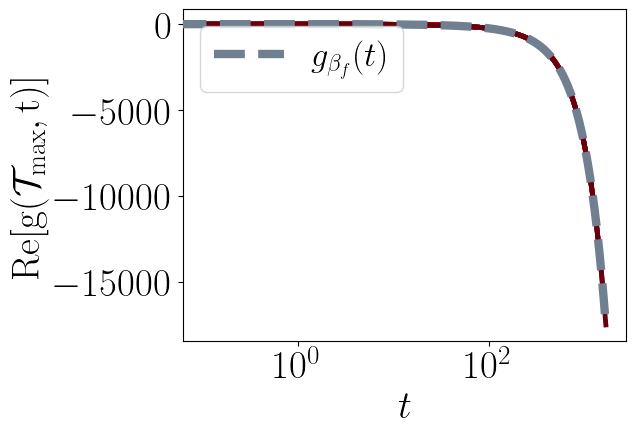

In [126]:
colors = plt.cm.Reds(np.linspace(0.3,1,len(Tau_times)))

fig, ax = plt.subplots(1, figsize= (bwidth,bheight)) 
plt.subplots_adjust(hspace=.0)

# plot equilibrium solution
ax.plot(t_, g_thermal.real,linewidth=6,  c='slategrey',zorder=5, linestyle='dashed', 
           label=r'$g_{\beta_{f}}(t)$')

i = 0
for tau in Tau_times:
    g_tau = Tau_dict[tau]
    tzero = int(len(g_tau)/2)
    # initial condition of derivative
    gprime = -(-g_tau[tzero+2] + 8*g_tau[tzero+1]-8*g_tau[tzero-1]+g_tau[tzero-2])/(12*(2*dt))
    g_tau = np.flip(g_tau[:tzero])
    t_ = np.linspace(0,len(g_tau)*dt*2,len(g_tau))
    # comparing the RHS and LHS of the thermal equation using the KB solution
    dg_lhs =  LHS(g_tau, gprime, dt)
    g_RHS = RHS(g_tau,J2_mag, Jq_mag)

    ax.plot(t_, g_tau.real,linewidth=3.5,linestyle='solid', c=colors[i])
    
    i = i+1
    
ax.set_xscale('log')

# aesthetics
ax.set_ylabel(r"$\rm{Re}[g(\mathcal{T}_{\rm max},t)]$")
ax.legend(fontsize=base_font-3)
ax.set_xlabel(r"$t$")
plt.tight_layout()

# plt.savefig(fig_route+'sep_Retau_Jtwo{:.3f}_sig{:.3f}.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)


# Energy Error as a function of J2 and Beta0

In the dataframe we have the relative error calcualted wrt to the mean of the final 500 steps of the iterations. I think  a better metric is to just calcualte the relative error wrt the final steps so this is what we do here

In [127]:
def get_energy_error_df(E_error_dict , data_route, name_list):
    for str_name in name_list:
        # get params
        J2_mag, Jq_mag, dt, maxt, sig = read_parameters(str_name)
        theta = np.arccos(sig/Jq_mag)
        beta0 = 2*theta*Jq_mag/sig
        # read the data
        f = h5py.File(data_route+str_name, 'r')

        # load energy and calcualte relative error
        Ekin = f["Energy"]["kinetic"][:]
        Eq = f["Energy"]["interaction"][:]
        Et1 = Ekin + Eq
        relError = abs((Et1[0] - Et1[-1])/Et1[0])

        E_error_dict["J2"].append(J2_mag)
        E_error_dict["beta0"].append(beta0)
        E_error_dict["relError"].append(relError)

        f.close()
        

In [128]:
# dictionary for the values
E_error_dict = { "beta0":[], "J2": [], "relError": []}

# i was a bit dumb so i have to do this by hand
data_route = "data_analysis/predictor_corrector/sigma0.15/"
name_list = [
    "Tdat_sig0.150_Jtwo0.003_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.004_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.005_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.006_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.007_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.008_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.009_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.010_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.030_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.040_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.050_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.060_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.150_Jtwo0.070_dt0.060_jq1.000_tmax1740.0.h5",
        ]

get_energy_error_df(E_error_dict , data_route,name_list)

data_route = "data_analysis/predictor_corrector/sigma0.3/"
name_list = [
    "Tdat_sig0.300_Jtwo0.003_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.004_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.005_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.006_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.007_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.008_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.009_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.010_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.020_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.030_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.040_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.050_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.060_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.300_Jtwo0.070_dt0.060_jq1.000_tmax1740.0.h5",
        ]

get_energy_error_df(E_error_dict , data_route,name_list)

data_route = "data_analysis/predictor_corrector/sigma0.74/"
name_list = [
    "Tdat_sig0.740_Jtwo0.003_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.004_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.005_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.006_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.007_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.008_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.009_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.010_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.030_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.040_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.050_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.060_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.740_Jtwo0.070_dt0.060_jq1.000_tmax1740.0.h5",
        ]

get_energy_error_df(E_error_dict , data_route,name_list)


# turn to data frame
pd.DataFrame.from_dict(E_error_dict)


data_route = "data_analysis/predictor_corrector/sigma0.95/"
name_list = [
    "Tdat_sig0.950_Jtwo0.003_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.004_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.005_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.006_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.007_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.008_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.009_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.010_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.030_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.040_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.050_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.060_dt0.060_jq1.000_tmax1740.0.h5",
    "Tdat_sig0.950_Jtwo0.070_dt0.060_jq1.000_tmax1740.0.h5",
        ]

get_energy_error_df(E_error_dict , data_route,name_list)


# turn to data frame
E_error_df = pd.DataFrame.from_dict(E_error_dict)
E_error_df["beta0"] = E_error_df["beta0"].round(decimals=1)

E_error_df.head()

,beta0,J2,relError
0,18.9,0.003,0.047759
1,18.9,0.004,0.043863
2,18.9,0.005,0.039614
3,18.9,0.006,0.035302
4,18.9,0.007,0.031142


/Users/rasputin/Desktop/Uni/PhD/hoping_chain_tensors/lib/python3.9/site-packages/seaborn/relational.py:438: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  points = ax.scatter(x=x, y=y, **kws)


AttributeError: Line2D.set() got an unexpected keyword argument 'cmap'

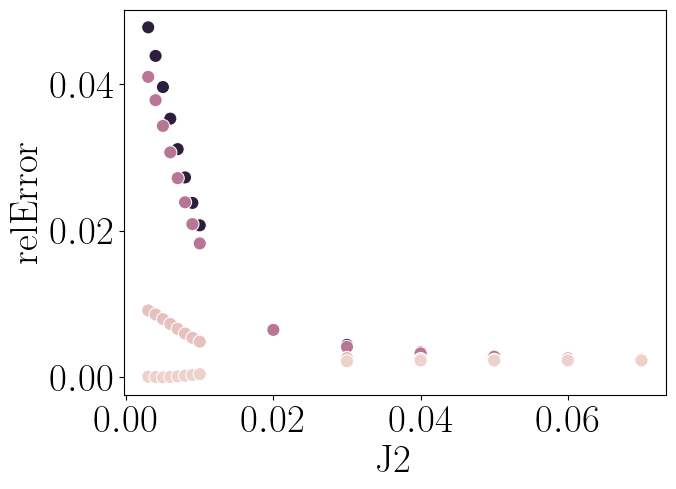

In [129]:

fig, ax = plt.subplots(1, figsize= (bwidth,bheight)) 

sns.scatterplot(data = E_error_df, x="J2", y="relError", hue="beta0", s=90, cmap="colorblind")

plt.legend(title=r'$\beta_0$', fontsize=base_font-3, bbox_to_anchor=(0.98, 1.0))

ax.set_xlabel(r"$\mathcal{J}_2$")
ax.set_ylabel(r"$|E_f - E_0 / E_0|$")
plt.tight_layout()

plt.savefig(fig_route+'error_vs_J2beta0.pdf',bbox_inches='tight',dpi=300)


# Goodness of fit

In [ ]:
data_df

In [ ]:
data_route = "data_analysis/predictor_corrector/sigma0.15/"

name_list = [
    "Tdat_sig0.150_Jtwo0.003_dt0.050_jq1.000_tmax1700.0.h5",
    "Tdat_sig0.150_Jtwo0.008_dt0.050_jq1.000_tmax1700.0.h5",
    "Tdat_sig0.150_Jtwo0.030_dt0.050_jq1.000_tmax1700.0.h5",
    "Tdat_sig0.150_Jtwo0.070_dt0.050_jq1.000_tmax1700.0.h5"
            ]

fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True, figsize= (1.5*bwidth,1.5*bheight)) 
# counter for plotting axes
k = 0
# i = row,  j = col
i = j = 0
for str_name in name_list:
    # counter so i can plot stuff in the correct place
    if k==0:
        i = j = 0
    elif k==1:
        i=0
        j=1
    elif k==2:
        i=1
        j=0
    elif k==3:
        i=1
        j=1
        
    J2_mag, Jq_mag, dt, maxt, sig = read_parameters(str_name)
    
    print(J2_mag)
    
    # read off the energy data
    f = h5py.File(data_route+str_name, 'r')
    
    # save the energy
    Ekin = f["Energy"]["kinetic"][:]
    Eq = f["Energy"]["interaction"][:]
    Et1 = Ekin + Eq
    time_range = f["Energy"]["timerange"][:]

    f.close()
    theta = np.arccos(sig/Jq_mag)
    beta0 = 2*theta*Jq_mag/sig
    print("initial beta =", beta0)
    
    # grab the fit values
    gamma_f = data_df[(data_df['J2']==J2_mag) & (data_df['sigma']==sig)]['EGamma'].values[0]
    const_f = data_df[(data_df['J2']==J2_mag) & (data_df['sigma']==sig)]['Econst'].values[0]
    amp_f = data_df[(data_df['J2']==J2_mag) & (data_df['sigma']==sig)]['Eampli'].values[0]

    # calculate the fiting function
    fit_range = time_range[np.where(time_range>=0)]
    K_fit = const_f + amp_f*np.exp(-gamma_f*fit_range)
    # plot the total energy
    #ax[i,j].plot(time_range, Et1.real,linewidth=6, c='black')
    # plot fit function
    ax[i,j].plot(fit_range, K_fit,linewidth=4, c='grey')
    # plot observed data
    ax[i,j].plot(time_range, Ekin.real,linewidth=5, c='blue', linestyle='dashed')
    
    # write down the J2 value
    ax[i,j].annotate(r'$\mathcal{{J}}_2={}$'.format(J2_mag), (420,-0.5))
            
    print(i,j)
    k=k+1
# put the labels

fig.text(0.56, 0.01, r'$t_1$', ha='center')
fig.text(0.002, 0.53, r'$\mathcal{K}(t_1)$', va='center', rotation='vertical')

plt.tight_layout()

plt.savefig(fig_route+'fit_accuracy.pdf'.format(J2_mag,sig),bbox_inches='tight',dpi=300)
